In [1]:
import sys
print(sys.executable)
print(sys.prefix)

# Just ensure you are using the right venv helps with cross contributor portability.
# the expected output should be something like 
# /Users/rishavbhagat/developer/ChartQA-IIITH/.venv/bin/python
# /Users/rishavbhagat/developer/ChartQA-IIITH/.venv

/Users/rishavbhagat/developer/ChartQA-IIITH/.venv/bin/python
/Users/rishavbhagat/developer/ChartQA-IIITH/.venv


# The begining of the basic data set exploration

Herin we start by having a look at the testing data only, 


In [26]:
PATHS = ["../datasets/HuggingFaceM4/ChartQA/data/train-00000-of-00003-49492f364babfa44.parquet", 
        "../datasets/HuggingFaceM4/ChartQA/data/train-00001-of-00003-7302bae5e425bbc7.parquet",
        "../datasets/HuggingFaceM4/ChartQA/data/train-00002-of-00003-194c9400785577a2.parquet" 
        ]

In [3]:
# import os
# import sys

# # 1. Print the location of the Python interpreter executable
# print("Python Executable:", sys.executable)

# # 2. Print the current working directory (where Python looks for relative paths)
# print("Current Working Directory:", os.getcwd())

# # 3. List files in the current working directory to see what is visible
# print("Files in current directory:", os.listdir("../datasets/HuggingFaceM4/ChartQA/data"))


In [4]:
import pandas as pd

# Load only the first few rows to inspect the structure

df_preview = pd.read_parquet(PATHS[0], engine="pyarrow").head()
print(df_preview.info())
print(df_preview.columns)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   image             5 non-null      object
 1   query             5 non-null      object
 2   label             5 non-null      object
 3   human_or_machine  5 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 288.0+ bytes
None
Index(['image', 'query', 'label', 'human_or_machine'], dtype='object')


In [5]:
import io
import matplotlib.pyplot as plt
from PIL import Image

def decode_chart_image(row, image_col='image'):
    val = row[image_col]
    if isinstance(val, dict) and 'bytes' in val:
        return Image.open(io.BytesIO(val['bytes']))
    elif isinstance(val, bytes):
        return Image.open(io.BytesIO(val))
    elif isinstance(val, str):
        return Image.open(val)
    else:
        raise ValueError("Unsupported image column format. Ensure it contains bytes or paths.")




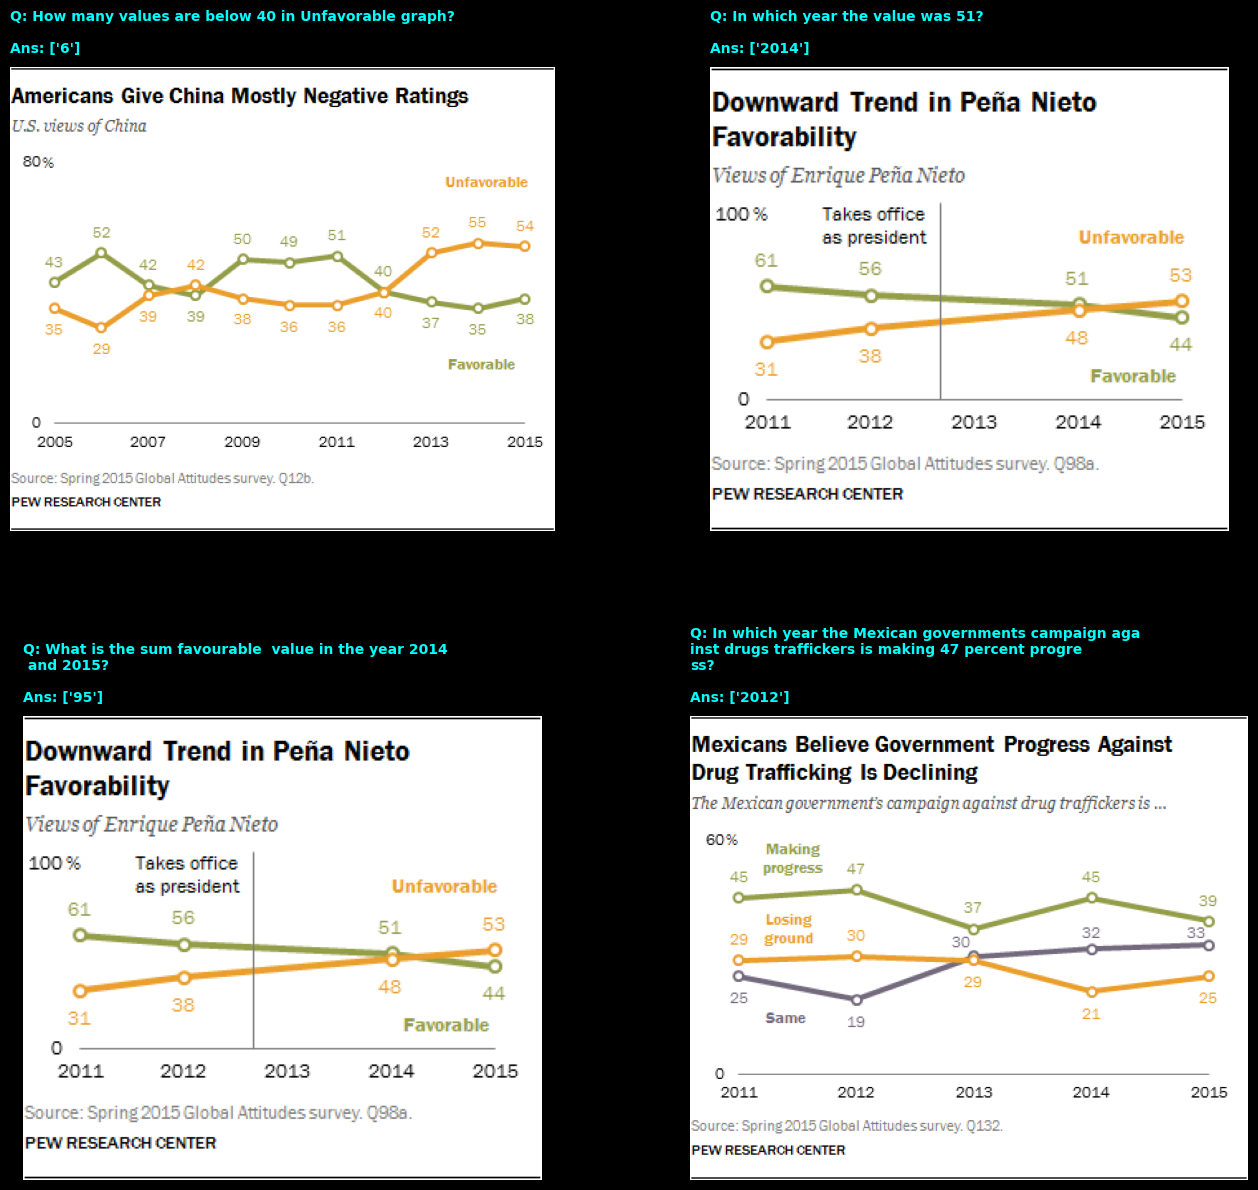

In [6]:
# Select 4 samples to inspect closely
sample_df = df_preview.head(40)

# Set up a grid layout (2 rows, 2 columns) with a dark facecolor
fig, axes = plt.subplots(2, 2, figsize=(14, 12), facecolor='black')
axes = axes.flatten()

for i, (_, row) in enumerate(sample_df.iterrows()):
    ax = axes[i -1]
    ax.set_facecolor('black')
    
    # Load and display chart image
    img = decode_chart_image(row)
    ax.imshow(img)
    ax.axis('off')
    
    # Extract query text and target answer label safely
    # Adjust string keys if your columns are named 'question' or 'answer'
    query_text = row.get('query', row.get('question', 'No Query Found'))
    label_text = row.get('label', row.get('answer', 'No Label Found'))
    
    # Wrap long questions so they fit nicely as titles
    wrapped_query = "\n".join([query_text[j:j+50] for j in range(0, len(query_text), 50)])
    
    # Title display (Cyan for query text, Green for ground truth label)
    ax.set_title(
        f"Q: {wrapped_query}\n\nAns: {label_text}", 
        color='#00ffff', 
        fontsize=10, 
        loc='left', 
        pad=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.subplots_adjust(hspace=0.4) # Add space for multi-line text titles
plt.show()


In [7]:
# checking the sort of questions and answers being asked

# Simple LLM run to categorise each query into certain buckets, 1. Quantitative, 2. NUmerical, 3. Reasoning, and similar for the answers, note we will do a shuffled sampling since the Population is arounf 32000, a sample of size 10 sampled 10 times randomly should work? or u suggest

In [21]:
from pathlib import Path

print(Path.cwd().parent/".env")

/Users/rishavbhagat/developer/ChartQA-IIITH/.env


In [27]:


sample_size = 350
IMG_COLS = ["image"]  # change to your image column name(s)

df_sample_train = []
for path in PATHS[:3]:
    df = pd.read_parquet(path, engine="pyarrow")
    df_sample_train.append(df.sample(n=sample_size, random_state=42).copy())

df_sample_train_0, df_sample_train_1, df_sample_train_2 = df_sample_train

# Show the data without the image columns
for i, d in enumerate(df_sample_train):
    print(f"--- sample {i}: {d.shape} ---")
    display(d.drop(columns=IMG_COLS, errors="ignore").head())

--- sample 0: (350, 4) ---


,query,label,human_or_machine
8588,What was the average wage for computer manufac...,[682],1
7268,Which age group has the highest point on this ...,[Under 25],0
3918,What is the fourth shortest bar?,[3822],0
8993,What is the projected number of people aware o...,[1572],1
265,What is the sum of the % who say that the ideo...,[50],0


--- sample 1: (350, 4) ---


,query,label,human_or_machine
8588,What was ranked first among the most popular m...,[Google Sites],1
7268,What percentage of votes did Sverigedemokrater...,[17.53],1
3918,When did illegal border crossings peak?,[2015],1
8993,What was the direct contribution of the travel...,[93.5],1
265,How many vessels did Petrobras own in 2020?,[30],1


--- sample 2: (350, 4) ---


,query,label,human_or_machine
8588,What is Northern Ireland's installed solar PV ...,[336],1
7268,What percentage of their total expenditure on ...,[29.9],1
3918,What was Twitter's net income in the last quar...,[68.01],1
8993,How much revenue did the Otto Group subsidiary...,[848],1
265,What was Missouri's highest unemployment rate ...,[9.5],1


In [ ]:
# import os
# import json
# import pandas as pd
# from tqdm import tqdm
# from pathlib import Path
# from litellm import completion
# from dotenv import load_dotenv

# load_dotenv(dotenv_path=Path.cwd().parent / ".env")
# if not os.getenv("DEEPSEEK_API_KEY"):
#     raise ValueError("DEEPSEEK_API_KEY not found in .env file or environment.")

# system_prompt = """
# You are a data evaluation assistant analyzing a ChartQA dataset. 
# Classify the given Chart Question (Query) and Answer into exactly one of these defined buckets.

# Query Categories:
# - "Quantitative": Asking for direct chart data extraction (e.g., "What is the value of X?").
# - "Numerical": Mathematical operations required (e.g., "Sum of X and Y", "Average growth").
# - "Reasoning": Requires logical synthesis, trends, or comparisons (e.g., "Which year performed worst?").

# Answer Categories:
# - "Pure Numerical": Just numbers (e.g., "45", "12.5").
# - "Alphanumeric/Units": Numbers containing metrics (e.g., "45%", "$12M").
# - "Descriptive Text": Pure string phrases (e.g., "Yes", "Blue bar").

# Respond ONLY with a valid JSON object matching this schema:
# {
#   "query_category": "Quantitative" | "Numerical" | "Reasoning",
#   "answer_category": "Pure Numerical" | "Alphanumeric/Units" | "Descriptive Text"
# }
# """

# output_dir = Path("./data/HuggingFaceM4/ChartQA/")
# output_dir.mkdir(parents=True, exist_ok=True)

# df_final_list = []

# for i, df_sample in enumerate(df_sample_train):
#     categorized_data = []
#     print(f"Sample {i}: sending {len(df_sample)} rows to the LLM...")

#     for _, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
#         query = str(row.get("query", row.get("question", "")))
#         answer = str(row.get("label", row.get("answer", "")))

#         try:
#             response = completion(
#                 model="deepseek/deepseek-chat",
#                 messages=[
#                     {"role": "system", "content": system_prompt},
#                     {"role": "user", "content": f"Query: {query}\nAnswer: {answer}"},
#                 ],
#                 response_format={"type": "json_object"},
#                 temperature=0.0,
#             )
#             categorized_data.append(json.loads(response.choices[0].message.content))
#         except Exception as e:
#             print(f"Error: {e}")
#             categorized_data.append({"query_category": "Unknown", "answer_category": "Unknown"})

#     df_res = pd.DataFrame(categorized_data)
#     df_final = pd.concat([df_sample.reset_index(drop=True), df_res], axis=1)
#     df_final_list.append(df_final)

#     output_path = output_dir / f"chartqa_categorized_sample_{i}.parquet"
#     df_final.to_parquet(output_path, index=False, engine="pyarrow")
#     print(f"Saved: {output_path}")

#     display(df_final.drop(columns=IMG_COLS, errors="ignore").head())

# df_final_0, df_final_1, df_final_2 = df_final_list

Sample 0: sending 350 rows to the LLM...


100%|██████████| 350/350 [04:35<00:00,  1.27it/s]


Saved: data/HuggingFaceM4/ChartQA/chartqa_categorized_sample_0.parquet


,query,label,human_or_machine,query_category,answer_category
0,What was the average wage for computer manufac...,[682],1,Numerical,Pure Numerical
1,Which age group has the highest point on this ...,[Under 25],0,Reasoning,Descriptive Text
2,What is the fourth shortest bar?,[3822],0,Reasoning,Pure Numerical
3,What is the projected number of people aware o...,[1572],1,Quantitative,Pure Numerical
4,What is the sum of the % who say that the ideo...,[50],0,Numerical,Pure Numerical


Sample 1: sending 350 rows to the LLM...


...

,query,label,human_or_machine,query_category,answer_category
0,What was ranked first among the most popular m...,[Google Sites],1,Reasoning,Descriptive Text
1,What percentage of votes did Sverigedemokrater...,[17.53],1,Quantitative,Pure Numerical
2,When did illegal border crossings peak?,[2015],1,Reasoning,Pure Numerical
3,What was the direct contribution of the travel...,[93.5],1,Quantitative,Pure Numerical
4,How many vessels did Petrobras own in 2020?,[30],1,Quantitative,Pure Numerical


Sample 2: sending 350 rows to the LLM...


100%|██████████| 350/350 [03:48<00:00,  1.53it/s]


Saved: data/HuggingFaceM4/ChartQA/chartqa_categorized_sample_2.parquet


,query,label,human_or_machine,query_category,answer_category
0,What is Northern Ireland's installed solar PV ...,[336],1,Quantitative,Pure Numerical
1,What percentage of their total expenditure on ...,[29.9],1,Quantitative,Alphanumeric/Units
2,What was Twitter's net income in the last quar...,[68.01],1,Quantitative,Pure Numerical
3,How much revenue did the Otto Group subsidiary...,[848],1,Quantitative,Pure Numerical
4,What was Missouri's highest unemployment rate ...,[9.5],1,Quantitative,Pure Numerical


## Inferences, Observations 